# Project Cycle 3 - Gender and Current Cigarette Use

## 1. Import Libraries

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep
)

## 2. Load and Inspect Dataset
Before conducting statistical analysis, the dataset must first be inspected to understand its structure, dimensions, and available variables.

This step helps verify that the required variables exist in the dataset and ensures the data can support the selected research question.

For this project, the analysis focuses on the relationship between gender and current cigarette use. Therefore, the variables `WhatIsYourSex` and `CurrentCigaretteUse` must be confirmed before further processing.

In [217]:
df = pd.read_csv("../data/raw/YRBS_2007.csv")

df.head()

,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


The first five rows of the dataset were displayed to verify that the dataset was successfully loaded into Python.

Previewing the dataset also helps identify the general structure of the variables and confirms that the selected variables are available for analysis.

In [218]:
df.shape

(14041, 103)

The dataset contains 14,041 observations and 103 variables.

The large sample size is appropriate for two-sample proportion inference because each comparison group is expected to contain sufficient observations.

In [219]:
df.columns

Index(['RaceEth', 'HowOldAreYou', 'WhatIsYourSex', 'InWhatGradeAreYou',
       'AreYouHispanicOrLatino', 'WhatIsYourRace',
       'HowTallAreYouWithoutShoesInMeters',
       'HowMuchDoYouWeighWithoutShoesInKG', 'BicyleHelmetUse', 'SeatBeltUse',
       ...
       'InjuredWhileExercising', 'HIVTesting', 'SunscreenUse', 'SunProtection',
       'Sleep', 'HealthInGeneral', 'BMIPCT', 'weight', 'stratum', 'psu'],
      dtype='object', length=103)

The variable names were inspected to confirm that the required variables for the research question were included in the dataset.

The variables `WhatIsYourSex` and `CurrentCigaretteUse` were successfully identified and will be used in subsequent analysis.

## 3. Select Variables
Only the variables relevant to the selected research question were retained for analysis.

The variable `WhatIsYourSex` was selected as the group variable, and `CurrentCigaretteUse` was selected as the response variable.

Selecting only the required variables helps simplify the analysis workflow and reduces unnecessary complexity from unrelated survey variables.

In [220]:
data = df[["WhatIsYourSex", "CurrentCigaretteUse"]].copy()

data.head()

,WhatIsYourSex,CurrentCigaretteUse
0,2.0,7.0
1,2.0,NaN
2,2.0,NaN
3,1.0,1.0
4,1.0,1.0


After variable selection, the analysis dataset contains 14,041 observations and 2 variables.

This reduced dataset is more suitable for focused statistical analysis and will be used for subsequent data cleaning and recoding procedures.

## 4. Data Cleaning and Recoding
Before conducting two-sample inference, the selected variables must be cleaned and recoded into analysis-ready formats.

The original survey variables contain categorical response codes that are not directly suitable for proportion inference.

Therefore, the dataset was cleaned to remove incomplete observations, and the response variable was recoded into a binary variable representing current cigarette use status.
### 4.1 Handle Missing Values
The dataset was checked for missing values before conducting statistical analysis.

The variable `WhatIsYourSex` contained 13 missing observations, while `CurrentCigaretteUse` contained 718 missing observations.

Because two-proportion inference requires both a clearly defined group variable and a valid binary response variable, observations with missing values were removed from the analysis dataset.

After removing incomplete observations, the cleaned dataset contained 13,312 observations and 2 variables.

This cleaning step helps improve the validity and consistency of the subsequent statistical analysis.

In [221]:
data.isnull().sum()

WhatIsYourSex           13
CurrentCigaretteUse    718
dtype: int64

In [222]:
data = data.dropna()

data.shape

(13312, 2)

### 4.2 Recode Variables
The original survey variables were recoded into analysis-ready variables before conducting statistical inference.

The variable `WhatIsYourSex` was recoded into a categorical variable named `sex`:
- 1 = Female
- 2 = Male

The variable `CurrentCigaretteUse` originally contained multiple categories representing smoking frequency during the past 30 days. However, the research question focuses on whether students currently use cigarettes rather than how frequently they smoke.

Therefore, the variable was converted into a binary variable named `current_smoker` using the following rule:
- 0 = no current cigarette use (original code 1)
- 1 = current cigarette use (original codes 2–7)

This binary recoding is necessary because the selected statistical method, the two-proportion z-test, requires a binary response variable representing success and failure outcomes.

After recoding, the distribution of `current_smoker` showed that most students were classified as non-current smokers, while a smaller proportion were classified as current smokers.

In [223]:
data["sex"] = data["WhatIsYourSex"].map({
    1: "Female",
    2: "Male"
})

data.head()

,WhatIsYourSex,CurrentCigaretteUse,sex
0,2.0,7.0,Male
3,1.0,1.0,Female
4,1.0,1.0,Female
5,1.0,1.0,Female
6,1.0,1.0,Female


In [224]:
data["current_smoker"] = np.where(
    data["CurrentCigaretteUse"].between(2, 7),
    1,
    0
)

data.head()

,WhatIsYourSex,CurrentCigaretteUse,sex,current_smoker
0,2.0,7.0,Male,1
3,1.0,1.0,Female,0
4,1.0,1.0,Female,0
5,1.0,1.0,Female,0
6,1.0,1.0,Female,0


In [225]:
data[["sex", "current_smoker"]].head()

,sex,current_smoker
0,Male,1
3,Female,0
4,Female,0
5,Female,0
6,Female,0


In [226]:
data["current_smoker"].value_counts()

current_smoker
0    10727
1     2585
Name: count, dtype: int64

### 4.3 Save Processed Data

In [227]:
processed_data = data[[
    "WhatIsYourSex",
    "CurrentCigaretteUse",
    "sex",
    "current_smoker"
]].copy()

processed_data.to_csv(
    "../data/processed/gender_smoking_cleaned.csv",
    index=False
)

processed_data.head()

,WhatIsYourSex,CurrentCigaretteUse,sex,current_smoker
0,2.0,7.0,Male,1
3,1.0,1.0,Female,0
4,1.0,1.0,Female,0
5,1.0,1.0,Female,0
6,1.0,1.0,Female,0


## 5. Descriptive Summary
Descriptive summaries were calculated to compare current cigarette use between male and female students before conducting formal statistical inference.

The cleaned dataset contained:
- 6,740 female students
- 6,572 male students

Among female students, 1,167 were classified as current smokers, corresponding to a smoking proportion of approximately 17.3%.

Among male students, 1,418 were classified as current smokers, corresponding to a smoking proportion of approximately 21.6%.

The estimated difference in smoking proportion between male and female students was approximately 0.043, indicating that the proportion of current cigarette use was higher among male students by about 4.3 percentage points.

In [228]:
summary = data.groupby("sex")["current_smoker"].agg(
    n="count",
    smokers="sum",
    proportion="mean"
)

summary.to_csv("../outputs/tables/gender_smoking_summary.csv")

summary

,n,smokers,proportion
sex,,,
Female,6740,1167,0.173145
Male,6572,1418,0.215764


In [229]:
p_male = summary.loc["Male", "proportion"]
p_female = summary.loc["Female", "proportion"]

difference = p_male - p_female

difference

0.042618446028561074

## 6. Visualization
A bar chart was created to visualize the smoking proportion for male and female students.

The figure shows that male students had a higher proportion of current cigarette use compared with female students.

The smoking proportion was approximately:
- 17.3% for female students
- 21.6% for male students

The difference between the two groups is visually observable, with male students showing a higher prevalence of current cigarette use.

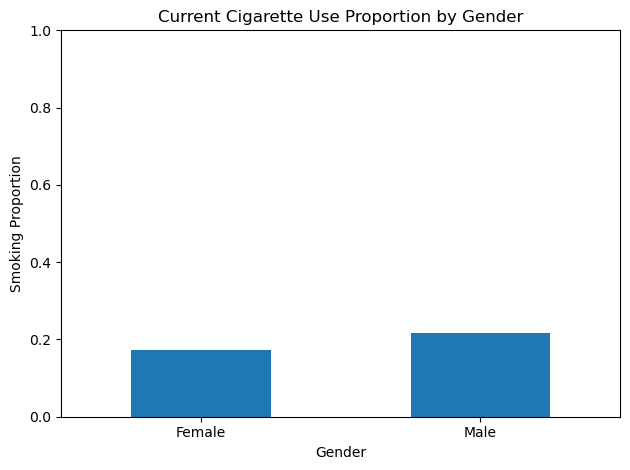

In [230]:
summary["proportion"].plot(kind="bar")

plt.title("Current Cigarette Use Proportion by Gender")
plt.xlabel("Gender")
plt.ylabel("Smoking Proportion")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../outputs/figures/smoking_proportion_by_gender.png")

plt.show()

## 7. Two-Proportion Z-Test
The two-proportion z-test was used to determine whether the proportion of current cigarette use differs between male and female students.

The hypotheses were defined as:

- Null hypothesis (\(H_0\)): the smoking proportions are equal between male and female students.
- Alternative hypothesis (\(H_1\)): the smoking proportions are different between male and female students.

### Assumptions

The two groups, male and female students, were treated as independent groups.

The response variable `current_smoker` was binary, with 1 representing current cigarette use and 0 representing no current cigarette use.

The sample sizes in both groups were large enough for two-proportion z-test because each group had sufficient numbers of smokers and non-smokers.

Therefore, the assumptions for two-proportion inference were considered reasonable.

In [231]:
count = np.array([
    summary.loc["Male", "smokers"],
    summary.loc["Female", "smokers"]
])

nobs = np.array([
    summary.loc["Male", "n"],
    summary.loc["Female", "n"]
])

z_stat, p_value = proportions_ztest(count, nobs)

z_stat, p_value

(6.214820309970149, 5.138341623910967e-10)

The two-proportion z-test produced a z-statistic of approximately 6.215 and a p-value smaller than 0.001.

Because the p-value was far below the significance level of 0.05, the null hypothesis was rejected.

This result suggests that the proportion of current cigarette use differs significantly between male and female students.

Based on the sample data, male students showed a higher proportion of current cigarette use than female students.

However, because the data are observational survey data, the result should be interpreted as an association rather than a causal relationship.

## 8. Confidence Interval
A 95% confidence interval was calculated to estimate the plausible range of the difference in smoking proportions between male and female students.

Unlike the hypothesis test, the confidence interval provides information about the magnitude and direction of the difference between groups.

In [232]:
ci_low, ci_high = confint_proportions_2indep(
    count1=summary.loc["Male", "smokers"],
    nobs1=summary.loc["Male", "n"],
    count2=summary.loc["Female", "smokers"],
    nobs2=summary.loc["Female", "n"],
    method="wald"
)

ci_low, ci_high

(0.029183277235416107, 0.05605361482170604)

The 95% confidence interval for the difference in smoking proportions between male and female students was approximately (0.029, 0.056).

This interval suggests that the true smoking proportion among male students is likely between 2.9 and 5.6 percentage points higher than that among female students.

Because the confidence interval does not include 0, the result supports the conclusion that the smoking proportions differ significantly between the two groups.

The confidence interval also indicates that the observed difference is not only statistically significant but also consistently positive in favor of higher smoking prevalence among male students.

## 9. Confidence Interval Visualization
### 9.1 Confidence Interval Plot
A confidence interval plot was created to visualize the estimated difference in smoking proportions between male and female students.

The horizontal reference line at 0 represents no difference between groups.

If the confidence interval does not cross 0, the difference is considered statistically significant at the 95% confidence level.

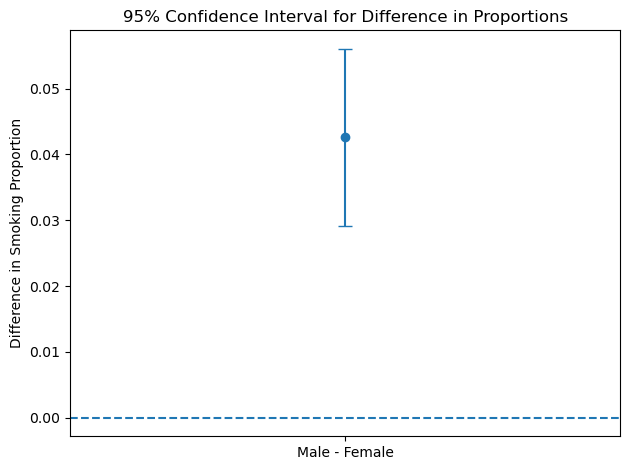

In [233]:
plt.errorbar(
    x=0,
    y=difference,
    yerr=[[difference - ci_low], [ci_high - difference]],
    fmt="o",
    capsize=5
)

plt.axhline(0, linestyle="--")

plt.xticks([0], ["Male - Female"])

plt.ylabel("Difference in Smoking Proportion")

plt.title("95% Confidence Interval for Difference in Proportions")

plt.tight_layout()

plt.savefig("../outputs/figures/ci_difference_smoking.png")

plt.show()

The confidence interval plot shows the estimated difference in smoking proportions between male and female students along with its 95% confidence interval.

The observed difference was positive, indicating that male students had a higher smoking proportion than female students.

Importantly, the entire confidence interval remained above 0, suggesting that the difference between groups is statistically significant at the 95% confidence level.

This visualization supports the conclusion that current cigarette use was more prevalent among male students in the dataset.

## 10. Final Interpretation
This study examined whether the proportion of current cigarette use differed between male and female students using the YRBS 2007 dataset.

Descriptive analysis showed that approximately 17.3% of female students and 21.6% of male students were classified as current smokers. The observed difference in smoking proportions was approximately 4.3 percentage points, with male students showing a higher prevalence of current cigarette use.

A two-proportion z-test was conducted to evaluate whether the observed difference was statistically significant. The test produced a z-statistic of approximately 6.215 and a p-value smaller than 0.001.

Because the p-value was below the significance level of 0.05, the null hypothesis was rejected. This result suggests that the smoking proportions between male and female students differ significantly.

The 95% confidence interval for the difference in smoking proportions was approximately (0.029, 0.056), indicating that the true smoking proportion among male students is likely between 2.9 and 5.6 percentage points higher than that among female students.

Overall, the analysis suggests that current cigarette use was more prevalent among male students in the dataset. However, because the data are observational survey data, the results should be interpreted as an association rather than a causal relationship.